In [33]:
import numpy as np
import pandas as pd
#import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', None)
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta

In [67]:
df_ev = pd.read_csv("data/cleaned_chargingdata.csv")
df_weather = pd.read_csv("data/cleaned_weather_data.csv")

In [36]:
df_ev

,Unnamed: 0.1,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture
0,0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,250.0,25.00,100.0,463.0,2020-01-02 05:09:39-08:00,True,2020-01-02 12:51:54-08:00
1,1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,280.0,70.00,250.0,595.0,2020-01-02 05:37:11-08:00,True,2020-01-02 15:31:50-08:00
2,2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,400.0,8.00,20.0,60.0,2020-01-02 05:57:17-08:00,True,2020-01-02 06:56:35-08:00
3,3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,400.0,8.00,20.0,65.0,2020-01-02 06:00:03-08:00,True,2020-01-02 07:04:58-08:00
4,4,3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,400.0,8.00,20.0,65.0,2020-01-02 06:00:19-08:00,True,2020-01-02 07:04:58-08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75324,80634,10083,5d574ad2f9af8b4c10c03652,2019-07-31 11:08:04-07:00,2019-07-31 16:29:18-07:00,2019-07-31 16:30:18-07:00,28.787,1_1_179_809_2019-07-31 18:08:04.432654,1,AG-3F27,1-1-179-809,America/Los_Angeles,393.0,240.0,31.20,130.0,355.0,2019-07-31 11:08:23-07:00,True,2019-07-31 17:03:04-07:00
75325,80635,10084,5d574ad2f9af8b4c10c03653,2019-07-31 11:40:41-07:00,2019-07-31 17:59:42-07:00,2019-07-31 14:44:23-07:00,7.787,1_1_179_810_2019-07-31 18:40:40.900203,1,AG-3F30,1-1-179-810,America/Los_Angeles,220.0,333.0,6.66,20.0,455.0,2019-07-31 11:41:02-07:00,True,2019-07-31 19:15:41-07:00
75326,80636,10085,5d574ad2f9af8b4c10c03654,2019-07-31 12:04:40-07:00,2019-07-31 15:44:22-07:00,2019-07-31 15:45:21-07:00,11.274,1_1_191_795_2019-07-31 19:04:40.098273,1,AG-4F51,1-1-191-795,America/Los_Angeles,1974.0,333.0,19.98,60.0,184.0,2019-07-31 12:04:57-07:00,True,2019-07-31 15:08:40-07:00
75327,80637,10086,5d574ad2f9af8b4c10c03655,2019-07-31 12:19:47-07:00,2019-07-31 17:34:51-07:00,2019-07-31 14:25:30-07:00,11.589,1_1_191_778_2019-07-31 19:19:46.919358,1,AG-4F43,1-1-191-778,America/Los_Angeles,942.0,275.0,22.00,80.0,60.0,2019-07-31 12:20:10-07:00,True,2019-07-31 13:19:47-07:00


In [37]:
df_ev['sessionID'].value_counts()

sessionID
1_1_179_779_2019-08-13 20:45:06.293662     58
1_1_178_824_2019-08-12 21:55:17.692457     46
1_1_194_822_2019-02-26 22:44:53.174959     32
2_39_79_379_2018-11-01 23:53:52.376186     27
2_39_131_30_2019-10-11 06:38:13.020209     25
                                           ..
2_39_124_558_2019-04-30 15:45:30.152741     1
2_39_123_23_2019-04-30 15:50:13.833702      1
2_39_92_442_2019-04-30 15:51:58.864062      1
2_39_79_377_2019-04-30 15:55:30.067900      1
1_1_193_819_2019-07-01 22:35:56.104381      1
Name: count, Length: 60950, dtype: int64

In [38]:
df_ev_ur = df_ev.drop_duplicates(subset='id', keep='first')


In [39]:
df_ev_ur.dtypes

Unnamed: 0.1            int64
Unnamed: 0              int64
id                     object
connectionTime         object
disconnectTime         object
doneChargingTime       object
kWhDelivered          float64
sessionID              object
siteID                  int64
spaceID                object
stationID              object
timezone               object
userID                float64
WhPerMile             float64
kWhRequested          float64
milesRequested        float64
minutesAvailable      float64
modifiedAt             object
paymentRequired          bool
requestedDeparture     object
dtype: object

In [40]:
# Remove timezone offset information from the string column before conversion
df_ev_ur['connectionTime'] = df_ev_ur['connectionTime'].str.replace(r'(-08:00)|(-07:00)', '', regex=True)
df_ev_ur['disconnectTime'] = df_ev_ur['disconnectTime'].str.replace(r'(-08:00)|(-07:00)', '', regex=True)
df_ev_ur['doneChargingTime'] = df_ev_ur['doneChargingTime'].str.replace(r'(-08:00)|(-07:00)', '', regex=True)

In [41]:
# Ensure the columns are converted to datetime 
df_ev_ur['connectionTime'] = pd.to_datetime(df_ev_ur['connectionTime'], errors='coerce')
df_ev_ur['disconnectTime'] = pd.to_datetime(df_ev_ur['disconnectTime'], errors='coerce')
df_ev_ur['doneChargingTime'] = pd.to_datetime(df_ev_ur['doneChargingTime'], errors='coerce')

In [42]:
df_ev_ur.dtypes

Unnamed: 0.1                   int64
Unnamed: 0                     int64
id                            object
connectionTime        datetime64[ns]
disconnectTime        datetime64[ns]
doneChargingTime      datetime64[ns]
kWhDelivered                 float64
sessionID                     object
siteID                         int64
spaceID                       object
stationID                     object
timezone                      object
userID                       float64
WhPerMile                    float64
kWhRequested                 float64
milesRequested               float64
minutesAvailable             float64
modifiedAt                    object
paymentRequired                 bool
requestedDeparture            object
dtype: object

In [43]:
df_ev_ur

,Unnamed: 0.1,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture
0,0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54,2020-01-02 11:11:15,2020-01-02 09:31:35,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,250.0,25.00,100.0,463.0,2020-01-02 05:09:39-08:00,True,2020-01-02 12:51:54-08:00
1,1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50,2020-01-02 14:38:21,2020-01-02 12:18:05,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,280.0,70.00,250.0,595.0,2020-01-02 05:37:11-08:00,True,2020-01-02 15:31:50-08:00
2,2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35,2020-01-02 16:39:22,2020-01-02 08:35:06,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,400.0,8.00,20.0,60.0,2020-01-02 05:57:17-08:00,True,2020-01-02 06:56:35-08:00
3,3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58,2020-01-02 08:38:39,2020-01-02 07:18:45,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,400.0,8.00,20.0,65.0,2020-01-02 06:00:03-08:00,True,2020-01-02 07:04:58-08:00
5,5,4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01,2020-01-02 14:08:40,2020-01-02 10:17:30,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,400.0,16.00,40.0,504.0,2020-01-02 06:00:13-08:00,True,2020-01-02 14:24:01-08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73563,78871,8670,5d2fbdd3f9af8b4d0dd0d54a,2019-07-01 14:49:12,2019-07-01 18:37:18,2019-07-01 16:14:33,8.399,1_1_179_798_2019-07-01 21:49:11.873404,1,AG-3F18,1-1-179-798,America/Los_Angeles,1346.0,400.0,32.00,80.0,36.0,2019-07-01 14:49:37-07:00,True,2019-07-01 15:25:12-07:00
73565,78873,8671,5d2fbdd3f9af8b4d0dd0d54b,2019-07-01 14:58:45,2019-07-01 17:39:48,2019-07-01 17:40:21,16.864,1_1_179_794_2019-07-01 21:58:44.571011,1,AG-3F20,1-1-179-794,America/Los_Angeles,364.0,400.0,40.00,100.0,234.0,2019-07-01 14:59:09-07:00,True,2019-07-01 18:52:45-07:00
73566,78874,8672,5d2fbdd3f9af8b4d0dd0d54c,2019-07-01 15:02:21,2019-07-01 17:58:50,2019-07-01 17:59:23,18.335,1_1_191_807_2019-07-01 22:02:20.810735,1,AG-4F47,1-1-191-807,America/Los_Angeles,2050.0,333.0,29.97,90.0,309.0,2019-07-01 15:02:37-07:00,True,2019-07-01 20:11:21-07:00
73568,78876,8673,5d2fbdd3f9af8b4d0dd0d54d,2019-07-01 15:23:44,2019-07-01 19:03:36,2019-07-01 19:04:06,22.815,1_1_179_781_2019-07-01 22:23:32.496137,1,AG-3F31,1-1-179-781,America/Los_Angeles,1626.0,200.0,34.00,170.0,99.0,2019-07-01 15:23:43-07:00,True,2019-07-01 17:02:44-07:00


In [44]:
df_ev_ur.spaceID.value_counts()

spaceID
CA-303     1745
CA-305     1363
AG-1F08    1359
AG-1F10    1198
AG-1F06    1151
           ... 
CA-509       86
CA-149       76
CA-505       74
CA-213       14
CA-148        8
Name: count, Length: 106, dtype: int64

In [45]:
site1 = df_ev_ur[df_ev_ur.siteID == 1]
site1.spaceID.unique()

array(['AG-3F30', 'AG-1F01', 'AG-1F03', 'AG-1F04', 'AG-1F06', 'AG-1F13',
       'AG-1F09', 'AG-4F34', 'AG-1F11', 'AG-1F08', 'AG-3F22', 'AG-1F14',
       'AG-1F07', 'AG-1F12', 'AG-3F29', 'AG-1F05', 'AG-3F18', 'AG-1F10',
       'AG-3F16', 'AG-4F37', 'AG-1F02', 'AG-3F28', 'AG-3F25', 'AG-3F24',
       'AG-3F33', 'AG-3F23', 'AG-3F31', 'AG-3F32', 'AG-3F27', 'AG-3F26',
       'AG-3F20', 'AG-3F17', 'AG-3F21', 'AG-3F19', 'AG-4F44', 'AG-4F52',
       'AG-4F41', 'AG-4F48', 'AG-4F35', 'AG-4F50', 'AG-3F15', 'AG-4F51',
       'AG-4F47', 'AG-4F46', 'AG-4F49', 'AG-4F43', 'AG-4F42', 'AG-4F45',
       'AG-4F36', 'AG-4F38', 'AG-4F40', 'AG-4F39'], dtype=object)

In [46]:
site2 = df_ev_ur[df_ev_ur.siteID == 2]
site2.spaceID.unique()

array(['CA-512', 'CA-327', 'CA-326', 'CA-303', 'CA-325', 'CA-311',
       'CA-309', 'CA-491', 'CA-493', 'CA-499', 'CA-323', 'CA-313',
       'CA-324', 'CA-513', 'CA-305', 'CA-317', 'CA-510', 'CA-315',
       'CA-321', 'CA-490', 'CA-497', 'CA-489', 'CA-319', 'CA-492',
       'CA-494', 'CA-502', 'CA-500', 'CA-495', 'CA-498', 'CA-304',
       'CA-307', 'CA-306', 'CA-501', 'CA-318', 'CA-308', 'CA-316',
       'CA-312', 'CA-320', 'CA-212', 'CA-508', 'CA-322', 'CA-314',
       'CA-503', 'CA-504', 'CA-496', 'CA-310', 'CA-506', 'CA-149',
       'CA-509', 'CA-507', 'CA-511', 'CA-213', 'CA-505', 'CA-148'],
      dtype=object)

## logic to compute hourly maximum observed utilization rate per site 

In [47]:
# Define the total number of spaces per site (example values)
total_spaces = {
    1: 52,  # Replace with the actual number of spaces for site 1
    2: 54   # Replace with the actual number of spaces for site 2
}

# Create a new DataFrame to hold hourly data
start_time = df_ev_ur['connectionTime'].min().replace(minute=0, second=0, microsecond=0)
end_time = df_ev_ur['disconnectTime'].max().replace(minute=0, second=0, microsecond=0) + timedelta(hours=1)

# Generate hourly intervals
times = pd.date_range(start=start_time, end=end_time, freq='H')
hourly_data = []

for time in times:
    # For each hour, calculate utilization for each site
    hourly_entry = {'hour': time}
    for site in total_spaces.keys():
        # Filter sessions active during the hour for the site
        active_sessions = df_ev_ur[(df_ev_ur['siteID'] == site) &
                             (df_ev_ur['connectionTime'] <= time + timedelta(hours=1)) &
                             (df_ev_ur['disconnectTime'] > time)]

        # Calculate utilization rate
        utilization = len(active_sessions['spaceID'].unique()) / total_spaces[site]
        hourly_entry[f'utilization_{site}'] = utilization

    hourly_data.append(hourly_entry)

# Create DataFrame for hourly utilization
hourly_df = pd.DataFrame(hourly_data)

# Display the result
hourly_df.head()

,hour,utilization_1,utilization_2
0,2018-04-25 04:00:00,0.0,0.018519
1,2018-04-25 05:00:00,0.0,0.018519
2,2018-04-25 06:00:00,0.0,0.055556
3,2018-04-25 07:00:00,0.0,0.129630
4,2018-04-25 08:00:00,0.0,0.407407


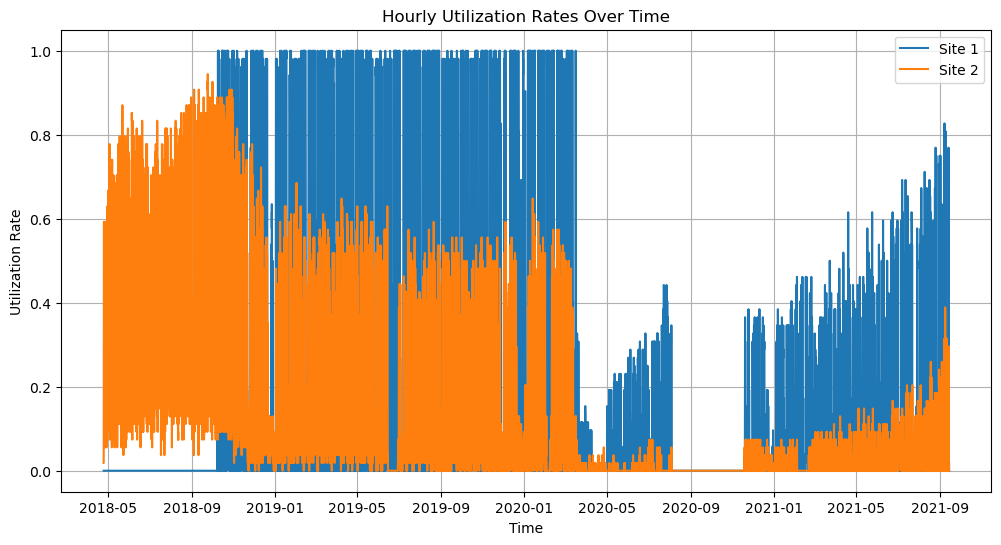

In [48]:
plt.figure(figsize=(12, 6))
for site in total_spaces.keys():
    plt.plot(hourly_df['hour'], hourly_df[f'utilization_{site}'], label=f'Site {site}')

plt.title('Hourly Utilization Rates Over Time')
plt.xlabel('Time')
plt.ylabel('Utilization Rate')
plt.legend()
plt.grid()
plt.show()


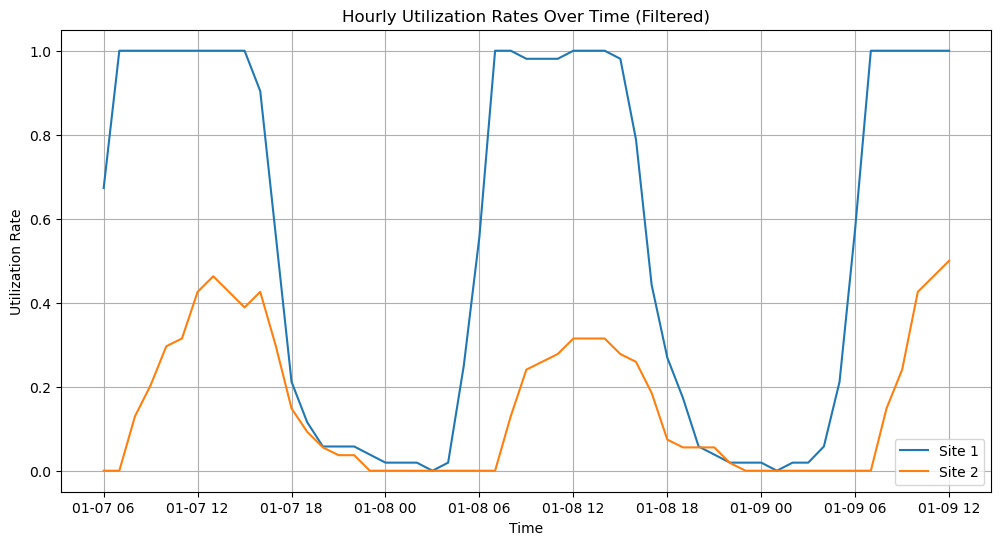

In [49]:
# Filter the timeframe
filtered_start_time = datetime(2020, 1, 7, 6, 0)  # Example start time
filtered_end_time = datetime(2020, 1, 9, 12, 0)  # Example end time
filtered_df = hourly_df[(hourly_df['hour'] >= filtered_start_time) & (hourly_df['hour'] <= filtered_end_time)]

# Visualization
plt.figure(figsize=(12, 6))
for site in total_spaces.keys():
    plt.plot(filtered_df['hour'], filtered_df[f'utilization_{site}'], label=f'Site {site}')

plt.title('Hourly Utilization Rates Over Time (Filtered)')
plt.xlabel('Time')
plt.ylabel('Utilization Rate')
plt.legend()
plt.grid()
plt.show()

## Verify correct computation: look at specific day and compare curve course with actual sessions for site1

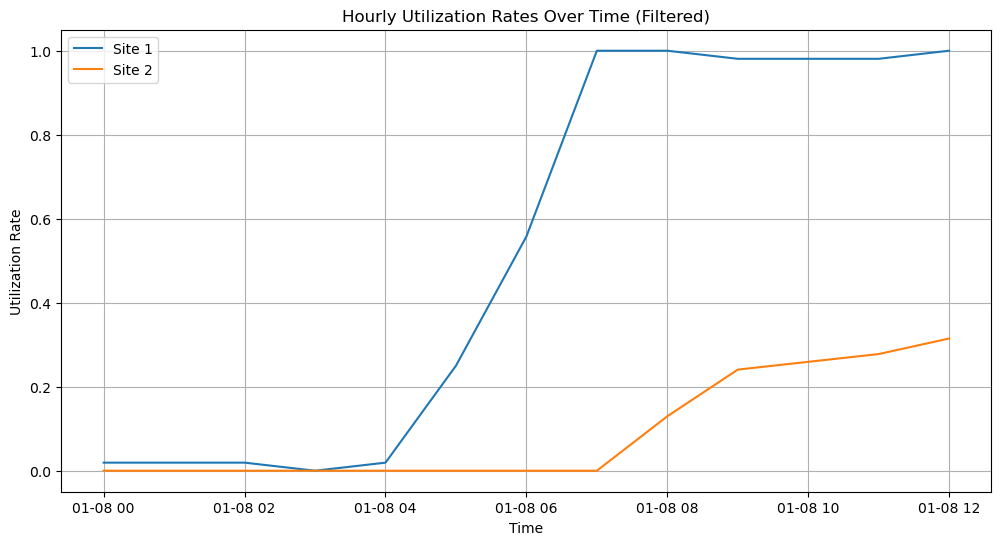

In [51]:
# Filter the timeframe
filtered_start_time = datetime(2020, 1, 8, 0, 0)  # Example start time
filtered_end_time = datetime(2020, 1, 8, 12, 0)  # Example end time
filtered_df = hourly_df[(hourly_df['hour'] >= filtered_start_time) & (hourly_df['hour'] <= filtered_end_time)]

# Visualization
plt.figure(figsize=(12, 6))
for site in total_spaces.keys():
    plt.plot(filtered_df['hour'], filtered_df[f'utilization_{site}'], label=f'Site {site}')

plt.title('Hourly Utilization Rates Over Time (Filtered)')
plt.xlabel('Time')
plt.ylabel('Utilization Rate')
plt.legend()
plt.grid()
plt.show()

### find all sessions on site1 with same timeframe

In [52]:
filtered_start_time = datetime(2020, 1, 8, 0, 0)  # Example start time
filtered_end_time = datetime(2020, 1, 8, 12, 0)  # Example end time
site1[(site1['connectionTime'] >= filtered_start_time) & (site1['connectionTime'] <= filtered_end_time)]

,Unnamed: 0.1,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture
296,296,234,5e2b9a62f9af8b7d745b12fe,2020-01-08 04:39:03,2020-01-08 17:00:49,2020-01-08 14:05:32,32.902000,1_1_194_826_2020-01-08 12:39:02.650912,1,AG-1F11,1-1-194-826,America/Los_Angeles,933.0,385.0,46.20,120.0,720.0,2020-01-08 04:39:21-08:00,True,2020-01-08 16:39:03-08:00
297,297,235,5e2b9a62f9af8b7d745b12ff,2020-01-08 05:02:37,2020-01-08 14:35:48,2020-01-08 08:03:47,5.807000,1_1_178_828_2020-01-08 13:02:37.451214,1,AG-1F10,1-1-178-828,America/Los_Angeles,3836.0,600.0,24.00,40.0,630.0,2020-01-08 05:02:42-08:00,True,2020-01-08 15:32:37-08:00
299,299,236,5e2b9a62f9af8b7d745b1300,2020-01-08 05:15:47,2020-01-08 14:51:34,2020-01-08 08:26:36,6.973000,1_1_178_817_2020-01-08 13:15:46.689203,1,AG-1F09,1-1-178-817,America/Los_Angeles,4147.0,500.0,10.00,20.0,355.0,2020-01-08 05:16:04-08:00,True,2020-01-08 11:10:47-08:00
300,300,237,5e2b9a62f9af8b7d745b1301,2020-01-08 05:37:21,2020-01-08 16:22:58,2020-01-08 11:32:17,12.843000,1_1_194_818_2020-01-08 13:37:08.307398,1,AG-1F14,1-1-194-818,America/Los_Angeles,2362.0,400.0,20.00,50.0,1272.0,2020-01-08 05:37:20-08:00,True,2020-01-09 02:49:21-08:00
302,302,238,5e2b9a62f9af8b7d745b1302,2020-01-08 05:40:58,2020-01-08 15:51:51,2020-01-08 11:25:36,10.771000,1_1_194_822_2020-01-08 13:40:58.412967,1,AG-1F12,1-1-194-822,America/Los_Angeles,3152.0,333.0,13.32,40.0,549.0,2020-01-08 05:41:09-08:00,True,2020-01-08 14:49:58-08:00
303,303,239,5e2b9a62f9af8b7d745b1303,2020-01-08 05:44:00,2020-01-08 15:27:22,2020-01-08 07:48:37,5.668000,1_1_191_789_2020-01-08 13:44:00.132687,1,AG-4F52,1-1-191-789,America/Los_Angeles,483.0,400.0,8.00,20.0,99.0,2020-01-08 05:44:08-08:00,True,2020-01-08 07:23:00-08:00
304,304,240,5e2b9a62f9af8b7d745b1304,2020-01-08 05:49:44,2020-01-08 13:44:59,2020-01-08 09:44:05,9.422000,1_1_194_821_2020-01-08 13:49:43.680659,1,AG-1F13,1-1-194-821,America/Los_Angeles,467.0,400.0,12.00,30.0,169.0,2020-01-08 05:49:49-08:00,True,2020-01-08 08:38:44-08:00
305,305,241,5e2b9a62f9af8b7d745b1305,2020-01-08 05:52:01,2020-01-08 11:50:45,2020-01-08 11:51:45,29.794000,1_1_193_825_2020-01-08 13:52:00.896135,1,AG-1F01,1-1-193-825,America/Los_Angeles,1733.0,400.0,40.00,100.0,720.0,2020-01-08 05:52:10-08:00,True,2020-01-08 17:52:01-08:00
306,306,242,5e2b9a62f9af8b7d745b1306,2020-01-08 05:53:54,2020-01-08 14:57:51,2020-01-08 09:43:27,13.272000,1_1_193_819_2020-01-08 13:53:54.069131,1,AG-1F06,1-1-193-819,America/Los_Angeles,651.0,400.0,20.00,50.0,226.0,2020-01-08 05:54:01-08:00,True,2020-01-08 09:39:54-08:00
307,307,243,5e2b9a62f9af8b7d745b1307,2020-01-08 05:53:56,2020-01-08 14:11:07,2020-01-08 14:12:07,31.705000,1_1_178_823_2020-01-08 13:53:35.928280,1,AG-1F08,1-1-178-823,America/Los_Angeles,3687.0,400.0,44.00,110.0,374.0,2020-01-08 05:53:56-08:00,True,2020-01-08 12:07:56-08:00


## -> seems legit, there is a gap in conncection times between 7:35 and 11:24. same behaviour can be seen in plot above, around 7:30 the utilization rate hits 100%, then declines a bit (some disconnected) and it starts to rise again around 11:30 

In [32]:
#hourly_df.to_csv('Utilization_Rate_Hourly.csv')

# Merge Weather Data

In [68]:
# remove UTC information from timestamp
df_weather['timestamp'] = df_weather['timestamp'].str.replace(r'(-08:00)|(-07:00)', '', regex=True)


In [69]:
df_weather

,Unnamed: 0,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature
0,0,2018-04-25 03:42:00,12.0,27.0,Mostly Cloudy,989.11,11.0,0.0,12.0
1,1,2018-04-25 03:53:00,12.0,26.0,Cloudy,989.11,11.0,0.0,12.0
2,2,2018-04-25 04:53:00,12.0,27.0,Mostly Cloudy,989.11,6.0,0.0,12.0
3,3,2018-04-25 05:10:00,12.0,27.0,Mostly Cloudy,989.11,7.0,0.0,12.0
4,4,2018-04-25 05:53:00,12.0,28.0,Mostly Cloudy,989.11,9.0,0.0,12.0
...,...,...,...,...,...,...,...,...,...
26204,26204,2020-12-31 19:53:00,13.0,33.0,Fair,986.81,0.0,0.0,13.0
26205,26205,2020-12-31 20:53:00,12.0,33.0,Fair,986.81,11.0,0.0,12.0
26206,26206,2020-12-31 21:53:00,12.0,33.0,Fair,987.47,9.0,0.0,12.0
26207,26207,2020-12-31 22:53:00,11.0,33.0,Fair,987.14,13.0,0.0,11.0


In [70]:
# Aggregation of df_weather to hourly values
def aggregate_weather(df_weather):
    df_weather['timestamp'] = pd.to_datetime(df_weather['timestamp'])
    df_weather.set_index('timestamp', inplace=True)

    aggregated = df_weather.resample('H').agg({
        'temperature': 'mean',
        'cloud_cover': 'mean',
        'pressure': 'mean',
        'windspeed': 'mean',
        'precipitation': 'mean',
        'felt_temperature': 'mean',
        'cloud_cover_description': lambda x: x.mode().iloc[0] if not x.mode().empty else None
    })

    aggregated.reset_index(inplace=True)
    return aggregated

In [71]:
aggregated_weather = aggregate_weather(df_weather)
aggregated_weather


,timestamp,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature,cloud_cover_description
0,2018-04-25 03:00:00,12.0,26.5,989.11,11.0,0.0,12.0,Cloudy
1,2018-04-25 04:00:00,12.0,27.0,989.11,6.0,0.0,12.0,Mostly Cloudy
2,2018-04-25 05:00:00,12.0,27.5,989.11,8.0,0.0,12.0,Mostly Cloudy
3,2018-04-25 06:00:00,12.0,20.0,989.44,8.0,0.0,12.0,Fog
4,2018-04-25 07:00:00,12.0,26.0,990.10,6.0,0.0,12.0,Cloudy
...,...,...,...,...,...,...,...,...
23560,2020-12-31 19:00:00,13.0,33.0,986.81,0.0,0.0,13.0,Fair
23561,2020-12-31 20:00:00,12.0,33.0,986.81,11.0,0.0,12.0,Fair
23562,2020-12-31 21:00:00,12.0,33.0,987.47,9.0,0.0,12.0,Fair
23563,2020-12-31 22:00:00,11.0,33.0,987.14,13.0,0.0,11.0,Fair


In [74]:
# Remove timestamps not in weather or EV data
hourly_df = hourly_df[hourly_df['hour'] <= datetime(2020, 12, 31, 23, 0)]

aggregated_weather = aggregated_weather[aggregated_weather['timestamp'] != datetime(2018, 4, 25, 3, 0)]


In [75]:
hourly_df

,hour,utilization_1,utilization_2
0,2018-04-25 04:00:00,0.0,0.018519
1,2018-04-25 05:00:00,0.0,0.018519
2,2018-04-25 06:00:00,0.0,0.055556
3,2018-04-25 07:00:00,0.0,0.129630
4,2018-04-25 08:00:00,0.0,0.407407
...,...,...,...
23559,2020-12-31 19:00:00,0.0,0.000000
23560,2020-12-31 20:00:00,0.0,0.000000
23561,2020-12-31 21:00:00,0.0,0.000000
23562,2020-12-31 22:00:00,0.0,0.000000


In [76]:
aggregated_weather

,timestamp,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature,cloud_cover_description
1,2018-04-25 04:00:00,12.0,27.0,989.11,6.0,0.0,12.0,Mostly Cloudy
2,2018-04-25 05:00:00,12.0,27.5,989.11,8.0,0.0,12.0,Mostly Cloudy
3,2018-04-25 06:00:00,12.0,20.0,989.44,8.0,0.0,12.0,Fog
4,2018-04-25 07:00:00,12.0,26.0,990.10,6.0,0.0,12.0,Cloudy
5,2018-04-25 08:00:00,13.5,21.0,990.10,6.0,0.0,13.5,Haze
...,...,...,...,...,...,...,...,...
23560,2020-12-31 19:00:00,13.0,33.0,986.81,0.0,0.0,13.0,Fair
23561,2020-12-31 20:00:00,12.0,33.0,986.81,11.0,0.0,12.0,Fair
23562,2020-12-31 21:00:00,12.0,33.0,987.47,9.0,0.0,12.0,Fair
23563,2020-12-31 22:00:00,11.0,33.0,987.14,13.0,0.0,11.0,Fair


In [78]:
# Merge hourly_df and aggregated_weather
def merge_hourly_data(hourly_df, aggregated_weather):
    merged_df = pd.merge(hourly_df, aggregated_weather, left_on='hour', right_on='timestamp', how='inner')
    merged_df.drop(columns=['timestamp'], inplace=True)  # Drop duplicate timestamp column
    return merged_df

In [79]:
merged_df = merge_hourly_data(hourly_df, aggregated_weather)
merged_df

,hour,utilization_1,utilization_2,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature,cloud_cover_description
0,2018-04-25 04:00:00,0.0,0.018519,12.0,27.0,989.11,6.0,0.0,12.0,Mostly Cloudy
1,2018-04-25 05:00:00,0.0,0.018519,12.0,27.5,989.11,8.0,0.0,12.0,Mostly Cloudy
2,2018-04-25 06:00:00,0.0,0.055556,12.0,20.0,989.44,8.0,0.0,12.0,Fog
3,2018-04-25 07:00:00,0.0,0.129630,12.0,26.0,990.10,6.0,0.0,12.0,Cloudy
4,2018-04-25 08:00:00,0.0,0.407407,13.5,21.0,990.10,6.0,0.0,13.5,Haze
...,...,...,...,...,...,...,...,...,...,...
23559,2020-12-31 19:00:00,0.0,0.000000,13.0,33.0,986.81,0.0,0.0,13.0,Fair
23560,2020-12-31 20:00:00,0.0,0.000000,12.0,33.0,986.81,11.0,0.0,12.0,Fair
23561,2020-12-31 21:00:00,0.0,0.000000,12.0,33.0,987.47,9.0,0.0,12.0,Fair
23562,2020-12-31 22:00:00,0.0,0.000000,11.0,33.0,987.14,13.0,0.0,11.0,Fair


In [98]:
# Split the merged_df into two datasets for utilization_1 and utilization_2
def split_merged_data(merged_df):
    # Split for utilization_1
    utilization_1_df = merged_df[merged_df['hour'] >= datetime(2018, 10, 8, 6, 0)].copy() # Filter rows where activity on site starts 
    utilization_1_df.drop(columns=['utilization_2'], inplace=True)

    # Split for utilization_2
    utilization_2_df = merged_df.copy()
    utilization_2_df.drop(columns=['utilization_1'], inplace=True)

    return utilization_1_df, utilization_2_df

In [103]:
utilization_1_df, utilization_2_df = split_merged_data(merged_df)


In [87]:
utilization_1_df

,hour,utilization_1,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature,cloud_cover_description
3986,2018-10-08 06:00:00,0.076923,13.000000,34.000000,982.53,0.0,0.0,13.000000,Fair
3987,2018-10-08 07:00:00,0.365385,14.333333,29.333333,982.86,0.0,0.0,14.333333,Partly Cloudy
3988,2018-10-08 08:00:00,0.365385,17.000000,30.000000,983.19,0.0,0.0,17.000000,Partly Cloudy
3989,2018-10-08 09:00:00,0.365385,18.000000,34.000000,983.19,6.0,0.0,18.000000,Fair
3990,2018-10-08 10:00:00,0.365385,20.000000,34.000000,983.19,7.0,0.0,20.000000,Fair
...,...,...,...,...,...,...,...,...,...
23559,2020-12-31 19:00:00,0.000000,13.000000,33.000000,986.81,0.0,0.0,13.000000,Fair
23560,2020-12-31 20:00:00,0.000000,12.000000,33.000000,986.81,11.0,0.0,12.000000,Fair
23561,2020-12-31 21:00:00,0.000000,12.000000,33.000000,987.47,9.0,0.0,12.000000,Fair
23562,2020-12-31 22:00:00,0.000000,11.000000,33.000000,987.14,13.0,0.0,11.000000,Fair


In [88]:
utilization_2_df

,hour,utilization_2,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature,cloud_cover_description
0,2018-04-25 04:00:00,0.018519,12.0,27.0,989.11,6.0,0.0,12.0,Mostly Cloudy
1,2018-04-25 05:00:00,0.018519,12.0,27.5,989.11,8.0,0.0,12.0,Mostly Cloudy
2,2018-04-25 06:00:00,0.055556,12.0,20.0,989.44,8.0,0.0,12.0,Fog
3,2018-04-25 07:00:00,0.129630,12.0,26.0,990.10,6.0,0.0,12.0,Cloudy
4,2018-04-25 08:00:00,0.407407,13.5,21.0,990.10,6.0,0.0,13.5,Haze
...,...,...,...,...,...,...,...,...,...
23559,2020-12-31 19:00:00,0.000000,13.0,33.0,986.81,0.0,0.0,13.0,Fair
23560,2020-12-31 20:00:00,0.000000,12.0,33.0,986.81,11.0,0.0,12.0,Fair
23561,2020-12-31 21:00:00,0.000000,12.0,33.0,987.47,9.0,0.0,12.0,Fair
23562,2020-12-31 22:00:00,0.000000,11.0,33.0,987.14,13.0,0.0,11.0,Fair


In [104]:
def add_features(df):
    df['is_weekend'] = df['hour'].dt.weekday.isin([5, 6]).astype(int)
    weekdays = ['is_monday', 'is_tuesday', 'is_wednesday', 'is_thursday', 'is_friday', 'is_saturday', 'is_sunday']
    for i, day in enumerate(weekdays):
        df[day] = (df['hour'].dt.weekday == i).astype(int)
    df['hour_of_day_sin'] = np.sin(2 * np.pi * df['hour'].dt.hour / 24)
    df['hour_of_day_cos'] = np.cos(2 * np.pi * df['hour'].dt.hour / 24)
    df['trend'] = (df['hour'] - df['hour'].min()).dt.days

    # Normalize monthly average utilization
    df['month'] = df['hour'].dt.month
    monthly_avg = df.groupby('month')['utilization_1' if 'utilization_1' in df else 'utilization_2'].mean()
    monthly_avg_normalized = monthly_avg / monthly_avg.max()
    df = df.merge(monthly_avg_normalized, on='month', suffixes=('', '_normalized'))
    

    # Add lagged utilization
    if 'utilization_1' in df:
        df['utilization_1_lagged'] = df['utilization_1'].shift(1)
        df.rename(columns={'utilization_1_normalized': 'monthly_util_normalized'}, inplace=True)
    if 'utilization_2' in df:
        df['utilization_2_lagged'] = df['utilization_2'].shift(1)
        df.rename(columns={'utilization_2_normalized': 'monthly_util_normalized'}, inplace=True)

    return df

In [105]:
utilization_1_df = add_features(utilization_1_df)
utilization_2_df = add_features(utilization_2_df)

In [106]:
utilization_1_df

,hour,utilization_1,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature,cloud_cover_description,is_weekend,...,is_thursday,is_friday,is_saturday,is_sunday,hour_of_day_sin,hour_of_day_cos,trend,month,monthly_util_normalized,utilization_1_lagged
0,2018-10-08 06:00:00,0.076923,13.000000,34.000000,982.53,0.0,0.0,13.000000,Fair,0,...,0,0,0,0,1.000000,6.123234e-17,0,10,0.708449,NaN
1,2018-10-08 07:00:00,0.365385,14.333333,29.333333,982.86,0.0,0.0,14.333333,Partly Cloudy,0,...,0,0,0,0,0.965926,-2.588190e-01,0,10,0.708449,0.076923
2,2018-10-08 08:00:00,0.365385,17.000000,30.000000,983.19,0.0,0.0,17.000000,Partly Cloudy,0,...,0,0,0,0,0.866025,-5.000000e-01,0,10,0.708449,0.365385
3,2018-10-08 09:00:00,0.365385,18.000000,34.000000,983.19,6.0,0.0,18.000000,Fair,0,...,0,0,0,0,0.707107,-7.071068e-01,0,10,0.708449,0.365385
4,2018-10-08 10:00:00,0.365385,20.000000,34.000000,983.19,7.0,0.0,20.000000,Fair,0,...,0,0,0,0,0.500000,-8.660254e-01,0,10,0.708449,0.365385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19573,2020-09-30 19:00:00,0.000000,33.000000,33.000000,984.50,11.0,0.0,30.000000,Fair,0,...,0,0,0,0,-0.965926,2.588190e-01,723,9,0.502474,0.000000
19574,2020-09-30 20:00:00,0.000000,32.000000,33.000000,984.83,9.0,0.0,29.000000,Fair,0,...,0,0,0,0,-0.866025,5.000000e-01,723,9,0.502474,0.000000
19575,2020-09-30 21:00:00,0.000000,32.000000,33.000000,984.83,30.0,0.0,29.000000,Fair,0,...,0,0,0,0,-0.707107,7.071068e-01,723,9,0.502474,0.000000
19576,2020-09-30 22:00:00,0.000000,31.000000,33.000000,985.16,17.0,0.0,28.000000,Fair,0,...,0,0,0,0,-0.500000,8.660254e-01,723,9,0.502474,0.000000


In [107]:
utilization_1_df.columns

Index(['hour', 'utilization_1', 'temperature', 'cloud_cover', 'pressure',
       'windspeed', 'precipitation', 'felt_temperature',
       'cloud_cover_description', 'is_weekend', 'is_monday', 'is_tuesday',
       'is_wednesday', 'is_thursday', 'is_friday', 'is_saturday', 'is_sunday',
       'hour_of_day_sin', 'hour_of_day_cos', 'trend', 'month',
       'monthly_util_normalized', 'utilization_1_lagged'],
      dtype='object')